In [1]:
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2
%aimport

Modules to reload:
all-except-skipped

Modules to skip:



In [5]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

proj_root = f'{os.environ["HOME"]}/gitlab/timer'
sys.path.append(proj_root)

In [90]:
from timer.fit import TransitFit

wd = os.path.join(proj_root, 'examples/v1298tau-m2')
fp = os.path.join(wd, 'fit.yaml')
fit_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fp = os.path.join(wd, 'sys.yaml')
sys_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fit = TransitFit(sys_params, fit_params, wd=wd)
# fit.build_model()
# fit.sample()

setting default: fixed = ['period', 'u_star']
setting default: fit_basis = duration
setting default: chromatic = False
setting default: include_mean = True
setting default: include_flare = False
setting default: unif = ['t0']
setting default: unif_nsig = 10
setting default: use_gp = False
setting default: tune = 2000
setting default: draws = 2000
setting default: chains = 2
setting default: clobber = False
setting default: inferencedata = False
setting default for m2g: add_bias = False
setting default for m2r: add_bias = False
setting default for m2i: add_bias = False
setting default for m2z: add_bias = False
setting default for m2g: quadratic = False
setting default for m2r: quadratic = False
setting default for m2i: quadratic = False
setting default for m2z: quadratic = False
setting default for m2g: trend = None
setting default for m2r: trend = None
setting default for m2i: trend = None
setting default for m2z: trend = None
setting default for m2g: trim_beg = None
setting default fo

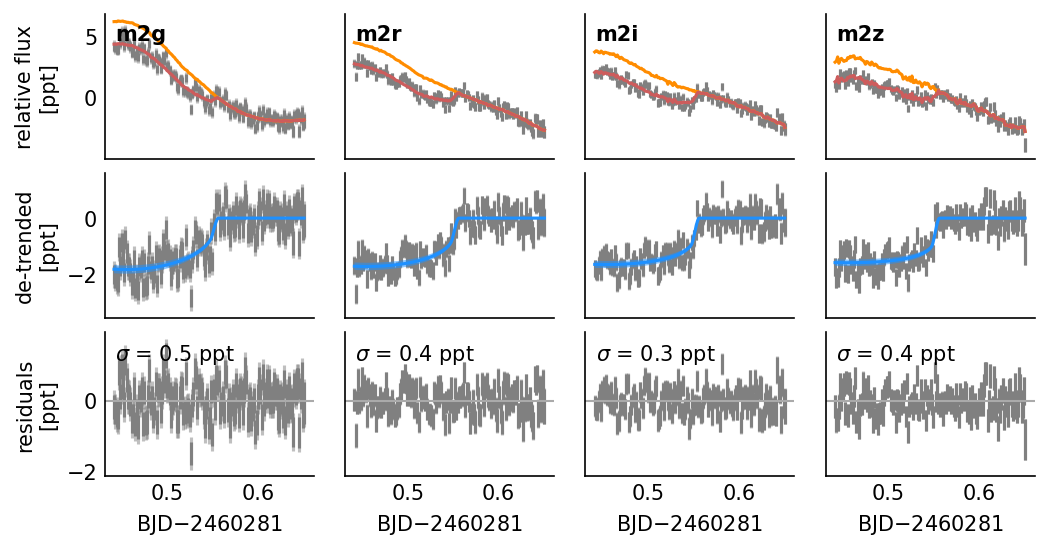

In [91]:
fit.plot_multi()

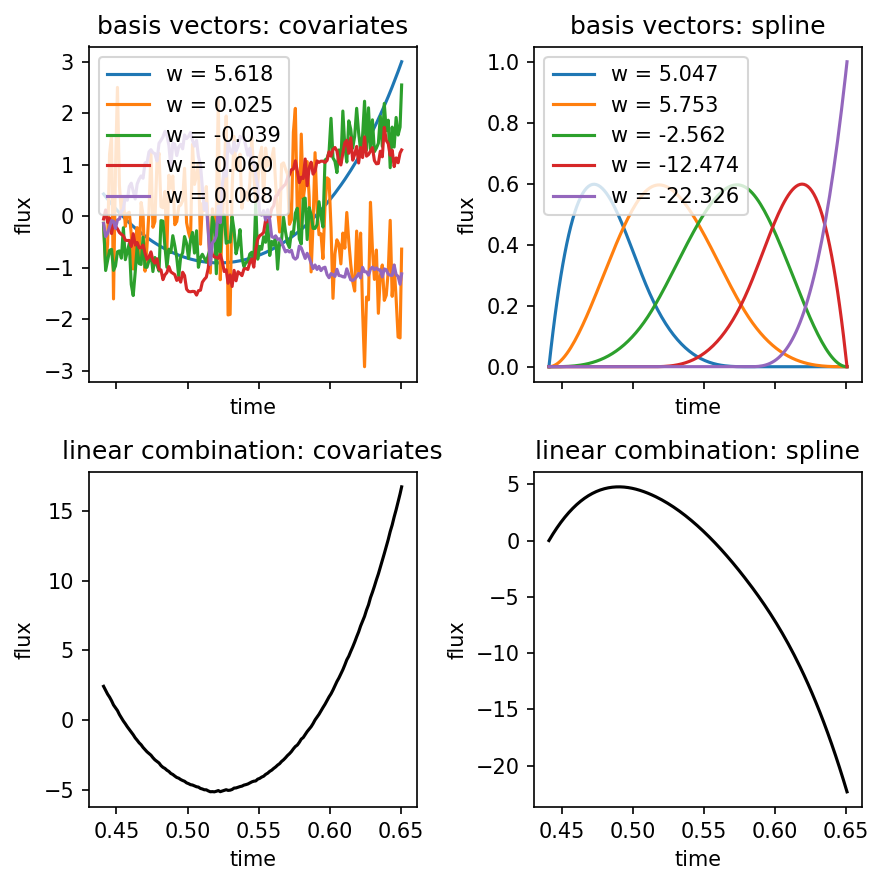

In [92]:
import numpy as np

# name = 'm3g'
name = 'm2g'
style = 1

# def plot_spline(fit, name, style=1):
spline = fit.fit_params['data'][name]['spline']
nspline = 5 if spline else 0    
trend = fit.fit_params['data'][name]['trend']
ntrend = trend if trend else 0
x = fit.data[name]['x']
X = fit.data[name]['X']
mask = fit.masks[name]
w = fit.map_soln[f'{name}_weights']
covariates = not nspline == X.shape[1]
ncovariates = X.shape[1] - nspline - ntrend

x_ = x[mask]
X_cov = X[mask,:ncovariates]
X_spl = X[mask,ncovariates:(ncovariates+nspline)]
w_cov = w[:ncovariates]
w_spl = w[ncovariates:(ncovariates+nspline)]

if style == 1:

    if covariates and spline:
        fig, axs = plt.subplots(2, 2, figsize=(6,6), sharex=True)
    elif covariates or spline:
        fig, axs = plt.subplots(2, 1, figsize=(3,6), sharex=True)

    def plot(axs, x, X, w, name):
        # axs[0].plot(x, X)
        for i,y in enumerate(X.T):
            axs[0].plot(x, y, label=f'w = {w[i] :.3f}')
        axs[0].legend()
        axs[1].plot(x, np.dot(X,w), color='k')
        plt.setp(axs[0], title=f'basis vectors: {name}')
        plt.setp(axs[1], title=f'linear combination: {name}')
        
    if covariates and not spline:
        plot(axs, x_, X_cov, w_cov, 'covariates')

    elif spline and not covariates:
        plot(axs, x_, X_spl, w_spl, 'spline')

    elif spline and covariates:
        plot(axs[:,0], x_, X_cov, w_cov, 'covariates')
        plot(axs[:,1], x_, X_spl, w_spl, 'spline')

    plt.setp(axs, xlabel='time', ylabel='flux')
    fig.tight_layout()

elif style == 2:

    if covariates and spline:
        nax = 2
        fig, axs = plt.subplots(1, 2, figsize=(6,3), sharex=True)
    elif covariates or spline:
        nax = 1
        fig, ax = plt.subplots(1, 1, figsize=(3,3), sharex=True)

    def plot(ax, x, X, w, name):
        for i,y in enumerate(X.T):
            ax.plot(x, y, label=f'w = {w[i] :.3f}')
        ax.plot(x, np.dot(X,w), color='k', label=f'sum')
        ax.legend()
        plt.setp(ax, title=f'{name}')

    if covariates and not spline:
        plot(ax, x_, X_cov, w_cov, 'covariates')
        
    elif spline and not covariates:
        plot(ax, x_, X_spl, w_spl, 'spline')

    elif spline and covariates:
        plot(axs[0], x_, X_cov, w_cov, 'covariates')
        plot(axs[1], x_, X_spl, w_spl, 'spline')

    if nax == 1:
        plt.setp(ax, xlabel='time', ylabel='flux')
    else:
        plt.setp(axs, xlabel='time', ylabel='flux')
    fig.tight_layout()

# plot_spline(fit, name)

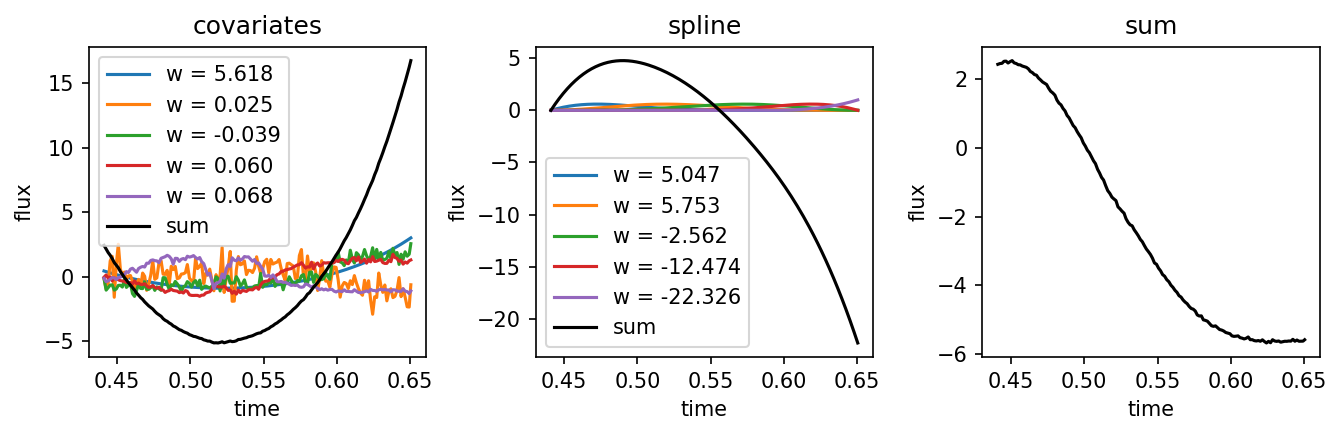

In [93]:
fit.plot_systematics(name, style=2)